## About the Dataset

This dataset contains satellite-detected wildfire hotspots, enriched with daily weather data, across seven fire-prone regions worldwide. It is designed for machine learning research focused on wildfire risk prediction, intensity classification, and seasonal pattern analysis.

### Coverage

- **Regions:** South Asia, Southeast Asia, Mediterranean, Sub-Saharan Africa, South America, North America, Australia  
- **Date Range:** January 2024 – December 2025  
- **Events:** 15,500 fire detection events across 35 countries  

### Features

- **latitude, longitude:** Geographic coordinates of the fire event  
- **acq_date:** Date of fire detection  
- **acq_time:** Time of fire detection (HHMM format)  
- **year, month:** Year and month of detection  
- **season:** Season of the year (e.g., summer, winter)  
- **daynight:** Indicates if the fire was detected during the day or night  
- **region:** Geographic region of the fire event  
- **country:** Country where the fire occurred  
- **fire_type:** Type of fire event (Wildfire, Agriculture, Peatland, Savanna)  
- **satellite:** Satellite used for detection (NOAA-20, Suomi-NPP)  
- **instrument:** Sensor/instrument used (VIIRS, MODIS)  
- **brightness_k:** Brightness temperature in Kelvin (related to fire activity)  
- **confidence:** Detection confidence level (high, nominal, low)  
- **temp_max_c:** Maximum air temperature on detection day (°C)  
- **wind_max_kmh:** Maximum wind speed (km/h), important for fire spread  
- **precip_mm:** Precipitation (proxy for fire suppression)  
- **humidity_pct:** Relative humidity (%)  

### Target Variable

- **fire_intensity:** Intensity level of the wildfire (categorical, 4 classes):  
    - 0 = Low  
    - 1 = Moderate  
    - 2 = High  
    - 3 = Extreme

In [303]:
# Importing essential libraries for data analysis and visualization
import numpy as np  # Numerical operations
import pandas as pd  # Data manipulation
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns  # Statistical data visualization
from sklearn.preprocessing import LabelEncoder  # For encoding for target variable
from sklearn.preprocessing import OneHotEncoder  # For encoding categorical features
from sklearn.preprocessing import StandardScaler  # For feature scaling

In [304]:
# Load the wildfire dataset for analysis
df = pd.read_csv("../data/raw/wildfire_multi_region_dataset.csv")  # Ensure the path is correct

#### Lets see the head and tail of the dataset to get a better understanding of the data.

In [305]:
# Display the first five rows to preview the data structure
df.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
0,-16.7722,151.0241,2024-01-01,1133,2024,1,Summer,D,Australia,Australia,...,TERRA,MODIS,347.72,29.38,Moderate,high,42.1,1.7,0.47,18.4
1,-41.1960,130.1397,2024-01-01,1251,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,357.82,62.05,High,nominal,43.8,2.2,0.27,11.7
2,-39.8750,124.9104,2024-01-02,1326,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,333.76,3.35,Low,high,35.4,4.4,0.35,5.0
3,-10.0978,149.8371,2024-01-02,206,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,323.94,46.35,Moderate,high,39.6,34.7,0.30,39.1
4,-12.4540,119.2301,2024-01-02,2054,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,359.59,434.80,Extreme,high,46.7,16.7,6.49,53.1


In [306]:
# Display the last five rows to check for any anomalies at the end of the dataset
df.tail()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
15495,-29.5180,4.4481,2025-10-31,912,2025,10,Spring,D,Sub_Saharan_Africa,DRC,...,Suomi-NPP,VIIRS,348.45,77.70,High,low,29.8,0.6,2.55,12.7
15496,1.8911,38.6745,2025-10-31,101,2025,10,Autumn,N,Sub_Saharan_Africa,South Africa,...,Suomi-NPP,VIIRS,339.74,78.96,High,high,35.7,0.5,1.13,7.9
15497,-3.7720,-16.7081,2025-10-31,136,2025,10,Spring,N,Sub_Saharan_Africa,Mozambique,...,TERRA,MODIS,350.10,221.90,Extreme,high,34.2,4.9,1.15,20.1
15498,6.5688,-12.5954,2025-10-31,313,2025,10,Autumn,N,Sub_Saharan_Africa,Angola,...,Suomi-NPP,VIIRS,356.97,68.71,High,low,46.9,17.4,1.72,28.2
15499,-27.7634,44.2033,2025-10-31,1224,2025,10,Spring,D,Sub_Saharan_Africa,Angola,...,Suomi-NPP,VIIRS,306.19,123.82,High,high,36.3,8.7,3.28,11.4


### Inspection of the dataset

In [307]:
# List all column names to understand available features
df.columns

Index(['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month',
       'season', 'daynight', 'region', 'country', 'fire_type', 'satellite',
       'instrument', 'brightness_k', 'frp_mw', 'fire_intensity', 'confidence',
       'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct'],
      dtype='str')

In [308]:
# Check the shape of the dataset (rows, columns)
df.shape

(15500, 21)

In [309]:
# Get a concise summary of the DataFrame, including non-null counts and dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        15500 non-null  float64
 1   longitude       15500 non-null  float64
 2   acq_date        15500 non-null  str    
 3   acq_time        15500 non-null  int64  
 4   year            15500 non-null  int64  
 5   month           15500 non-null  int64  
 6   season          15500 non-null  str    
 7   daynight        15500 non-null  str    
 8   region          15500 non-null  str    
 9   country         15500 non-null  str    
 10  fire_type       15500 non-null  str    
 11  satellite       15500 non-null  str    
 12  instrument      15500 non-null  str    
 13  brightness_k    15500 non-null  float64
 14  frp_mw          15500 non-null  float64
 15  fire_intensity  15500 non-null  str    
 16  confidence      15500 non-null  str    
 17  temp_max_c      15500 non-null  float64
 1

In [310]:
# Count the number of columns by data type
df.dtypes.value_counts()

str        10
float64     8
int64       3
Name: count, dtype: int64

In [311]:
# Generate descriptive statistics for numerical features
df.describe()

,latitude,longitude,acq_time,year,month,brightness_k,frp_mw,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000
mean,10.251489,29.204768,1177.268645,2024.503032,7.244774,336.501241,80.181982,35.099335,17.783774,2.595579,38.136716
std,24.367098,78.693275,689.540417,0.500007,2.768195,19.209340,150.411669,5.850954,17.617369,3.154769,18.890952
min,-42.990800,-167.990600,0.000000,2024.000000,1.000000,290.000000,0.370000,12.800000,0.000000,0.000000,5.000000
25%,-7.561575,-41.641000,600.000000,2024.000000,5.000000,324.570000,15.010000,31.000000,5.100000,0.610000,24.300000
50%,10.477350,34.807950,1200.000000,2025.000000,8.000000,335.170000,35.445000,35.200000,12.500000,1.520000,36.300000
75%,30.104450,95.064200,1756.000000,2025.000000,9.000000,346.670000,83.720000,39.200000,24.700000,3.330000,50.800000
max,69.982600,153.987500,2359.000000,2025.000000,12.000000,574.860000,3000.000000,55.500000,188.800000,34.440000,95.000000


In [312]:
missing_val=df.isnull().sum()

In [313]:
if missing_val.sum() == 0:
    print("No missing values in the dataset.")
else:
    print("Missing values detected in the dataset:")
    print(missing_val[missing_val > 0])

No missing values in the dataset.


In [314]:
# checking duplxate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


In [315]:
df.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
0,-16.7722,151.0241,2024-01-01,1133,2024,1,Summer,D,Australia,Australia,...,TERRA,MODIS,347.72,29.38,Moderate,high,42.1,1.7,0.47,18.4
1,-41.1960,130.1397,2024-01-01,1251,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,357.82,62.05,High,nominal,43.8,2.2,0.27,11.7
2,-39.8750,124.9104,2024-01-02,1326,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,333.76,3.35,Low,high,35.4,4.4,0.35,5.0
3,-10.0978,149.8371,2024-01-02,206,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,323.94,46.35,Moderate,high,39.6,34.7,0.30,39.1
4,-12.4540,119.2301,2024-01-02,2054,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,359.59,434.80,Extreme,high,46.7,16.7,6.49,53.1


In [316]:
# Data Conversion: Convert 'date' column to datetime format for easier manipulation
df['date'] = pd.to_datetime(df['acq_date'], errors='coerce')  #

In [317]:
df['date']

0       2024-01-01
1       2024-01-01
2       2024-01-02
3       2024-01-02
4       2024-01-02
           ...    
15495   2025-10-31
15496   2025-10-31
15497   2025-10-31
15498   2025-10-31
15499   2025-10-31
Name: date, Length: 15500, dtype: datetime64[us]

In [318]:
# lets make time also in  HH:MM:SS format
df['time'] = pd.to_datetime(df['acq_time'], format='%H%M', errors='coerce').dt.time

In [319]:
df['time']

0        11:33:00
1        12:51:00
2        13:26:00
3        20:06:00
4        20:54:00
           ...   
15495    09:12:00
15496    10:01:00
15497    13:06:00
15498    03:13:00
15499    12:24:00
Name: time, Length: 15500, dtype: object

In [320]:
# Feature Engineering: Extracting year, month, and day from the 'date' column for temporal analysis
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday 

In [321]:
df.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,date,time,day,weekday
0,-16.7722,151.0241,2024-01-01,1133,2024,1,Summer,D,Australia,Australia,...,Moderate,high,42.1,1.7,0.47,18.4,2024-01-01,11:33:00,1,0
1,-41.1960,130.1397,2024-01-01,1251,2024,1,Summer,D,Australia,Australia,...,High,nominal,43.8,2.2,0.27,11.7,2024-01-01,12:51:00,1,0
2,-39.8750,124.9104,2024-01-02,1326,2024,1,Summer,D,Australia,Australia,...,Low,high,35.4,4.4,0.35,5.0,2024-01-02,13:26:00,2,1
3,-10.0978,149.8371,2024-01-02,206,2024,1,Summer,N,Australia,Australia,...,Moderate,high,39.6,34.7,0.30,39.1,2024-01-02,20:06:00,2,1
4,-12.4540,119.2301,2024-01-02,2054,2024,1,Summer,N,Australia,Australia,...,Extreme,high,46.7,16.7,6.49,53.1,2024-01-02,20:54:00,2,1


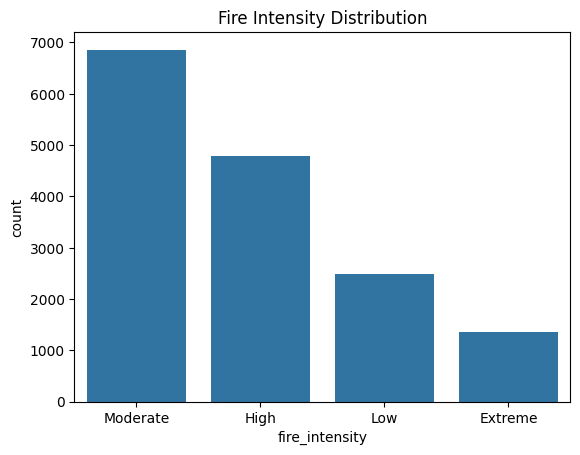

In [322]:
# Fire Intensity Distribution
sns.countplot(x='fire_intensity', data=df)
plt.title("Fire Intensity Distribution")
plt.show()

In [323]:
# Split the numerical and categorical features for preprocessing
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()


C:\Users\arunp\AppData\Local\Temp\ipykernel_46000\4174921380.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.tolist()


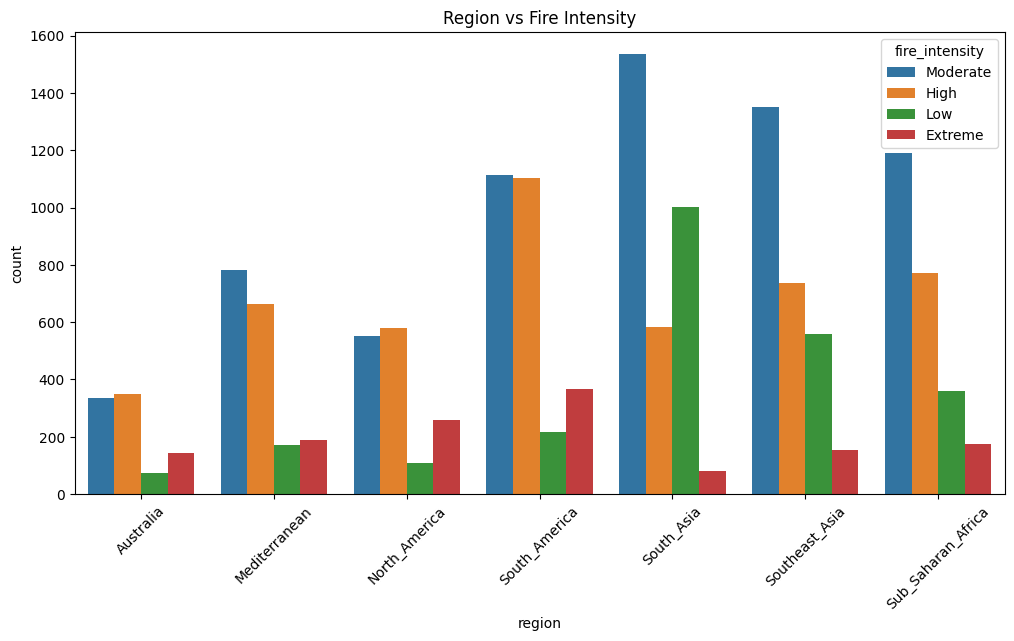

In [324]:
# Region vs Fire Intensity
plt.figure(figsize=(12,6))
sns.countplot(x='region', hue='fire_intensity', data=df)
plt.title("Region vs Fire Intensity")
plt.xticks(rotation=45)
plt.show()


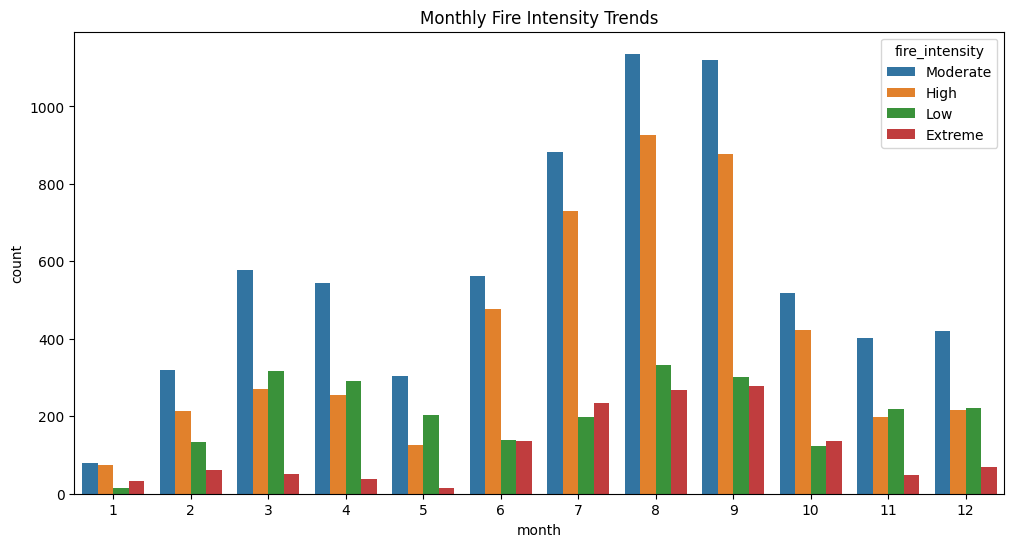

In [325]:
# TEMPORAL ANALYSIS
# Monthly Fire Intensity Trends
plt.figure(figsize=(12,6))
sns.countplot(x='month', hue='fire_intensity', data=df)
plt.title("Monthly Fire Intensity Trends")
plt.show()



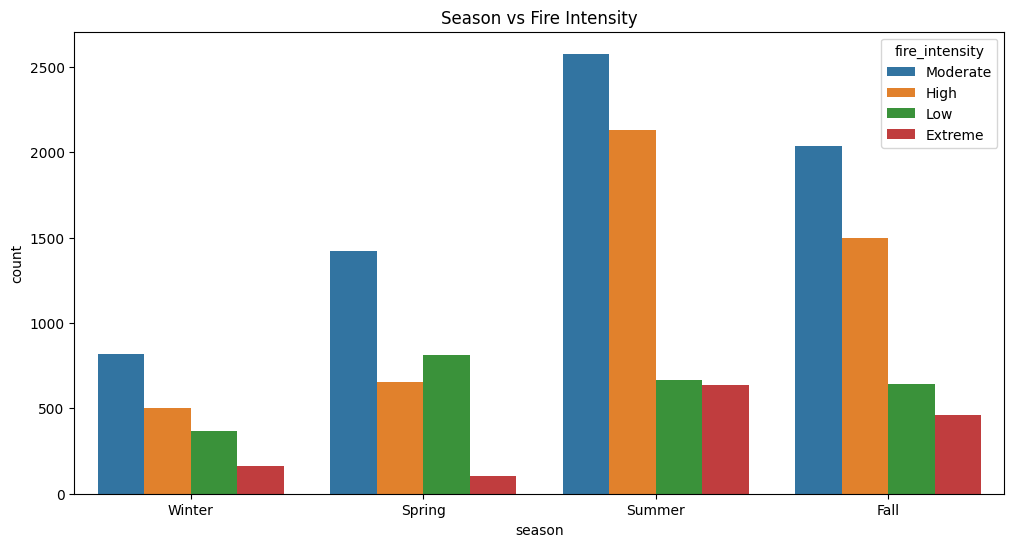

In [326]:
# Season Effect Vs Fire Intensity
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'
df['season'] = df['month'].apply(get_season)
plt.figure(figsize=(12,6))
sns.countplot(x='season', hue='fire_intensity', data=df, order=['Winter', 'Spring', 'Summer', 'Fall'])
plt.title("Season vs Fire Intensity")
plt.show()

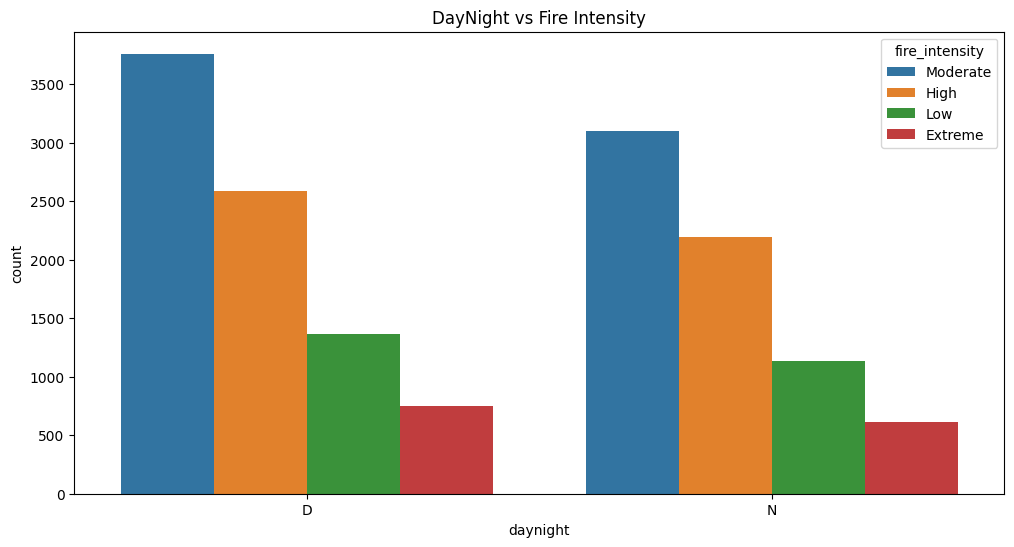

In [327]:
# DayNight vs Fire Intensity
plt.figure(figsize=(12,6))
sns.countplot(x='daynight', hue='fire_intensity', data=df)
plt.title("DayNight vs Fire Intensity")
plt.show()

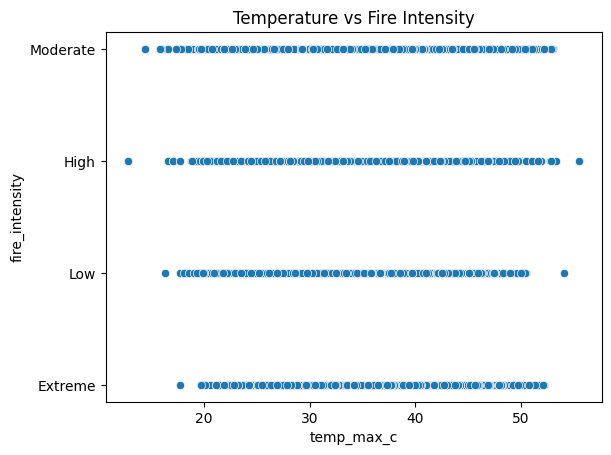

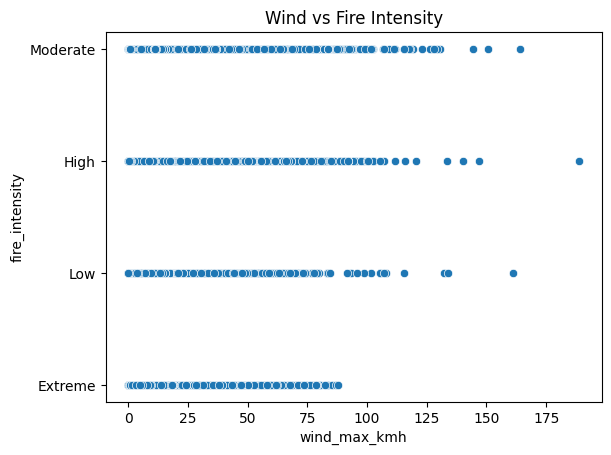

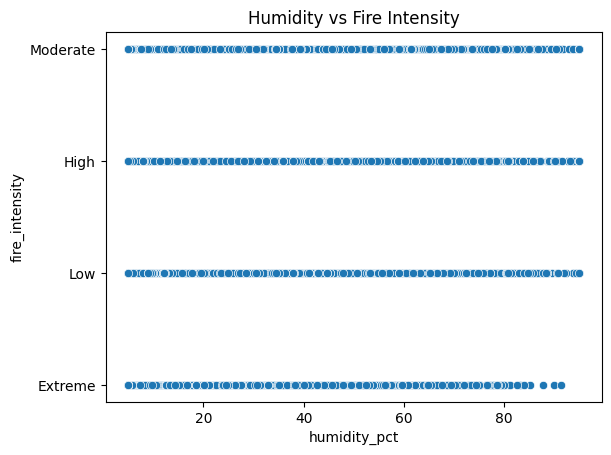

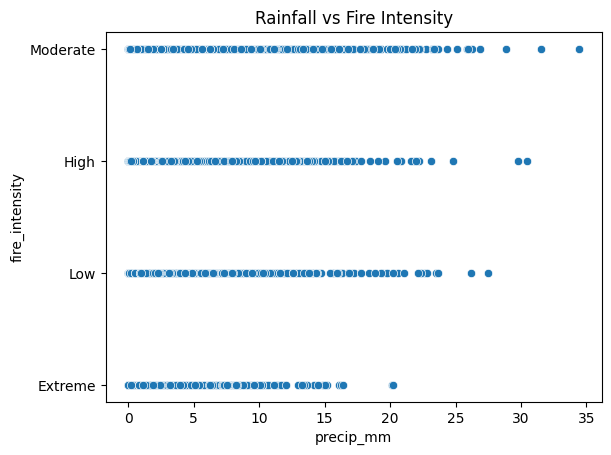

In [328]:

# Temperature vs Fire Intensity
sns.scatterplot(x="temp_max_c", y="fire_intensity", data=df)
plt.title("Temperature vs Fire Intensity")
plt.show()

# Wind vs Fire Intensity
sns.scatterplot(x="wind_max_kmh", y="fire_intensity", data=df)
plt.title("Wind vs Fire Intensity")
plt.show()

# Humidity vs Fire Intensity
sns.scatterplot(x="humidity_pct", y="fire_intensity", data=df)
plt.title("Humidity vs Fire Intensity")
plt.show()

# Precipitation vs Fire Intensity
sns.scatterplot(x="precip_mm", y="fire_intensity", data=df)
plt.title("Rainfall vs Fire Intensity")
plt.show()

In [329]:
numerical_features, categorical_features

(['latitude',
  'longitude',
  'acq_time',
  'brightness_k',
  'frp_mw',
  'temp_max_c',
  'wind_max_kmh',
  'precip_mm',
  'humidity_pct'],
 ['acq_date',
  'season',
  'daynight',
  'region',
  'country',
  'fire_type',
  'satellite',
  'instrument',
  'fire_intensity',
  'confidence',
  'time'])

In [330]:
# Data Preprocessing

In [331]:
# Lets Encode the target variable 'fire_intensity' using Label Encoding 
le = LabelEncoder()
df['fire_intensity_encoded'] = le.fit_transform(df['fire_intensity'])


In [332]:
df[['fire_intensity', 'fire_intensity_encoded']].head()

,fire_intensity,fire_intensity_encoded
0,Moderate,3
1,High,1
2,Low,2
3,Moderate,3
4,Extreme,0


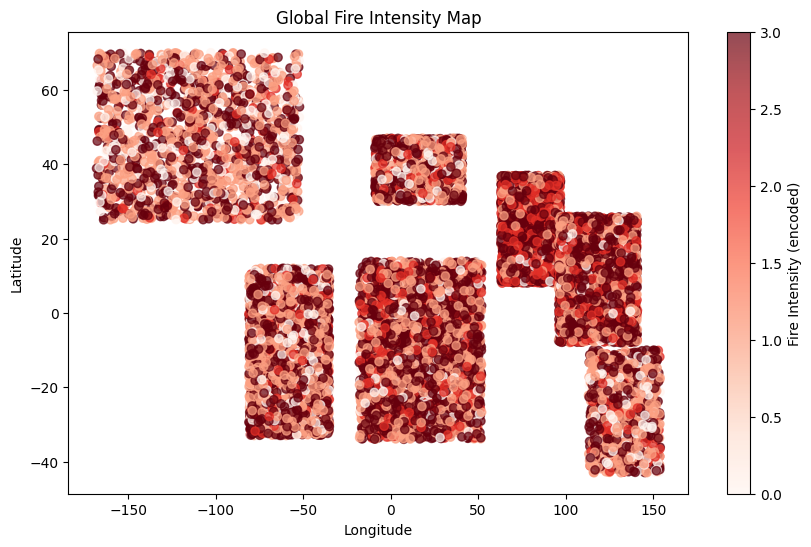

In [333]:
plt.figure(figsize=(10,6))
scatter = plt.scatter(df["longitude"], df["latitude"], c=df["fire_intensity_encoded"], cmap='Reds', alpha=0.7)
plt.colorbar(scatter, label="Fire Intensity (encoded)")
plt.title("Global Fire Intensity Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [334]:
# Remove problematic columns from categorical_features
safe_categorical_features = [col for col in categorical_features if col not in ['acq_date', 'time']]

encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_features = encoder.fit_transform(df[safe_categorical_features])
encoded_feature_names = encoder.get_feature_names_out(safe_categorical_features)
encoded_df = pd.DataFrame(encoded_features, columns=encoded_feature_names)
encoded_df.head()


,season_Spring,season_Summer,season_Winter,daynight_N,region_Mediterranean,region_North_America,region_South_America,region_South_Asia,region_Southeast_Asia,region_Sub_Saharan_Africa,...,fire_type_Wildfire,satellite_NOAA-20,satellite_Suomi-NPP,satellite_TERRA,instrument_VIIRS,fire_intensity_High,fire_intensity_Low,fire_intensity_Moderate,confidence_low,confidence_nominal
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [335]:
df.head()  

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,date,time,day,weekday,fire_intensity_encoded
0,-16.7722,151.0241,2024-01-01,1133,2024,1,Winter,D,Australia,Australia,...,high,42.1,1.7,0.47,18.4,2024-01-01,11:33:00,1,0,3
1,-41.1960,130.1397,2024-01-01,1251,2024,1,Winter,D,Australia,Australia,...,nominal,43.8,2.2,0.27,11.7,2024-01-01,12:51:00,1,0,1
2,-39.8750,124.9104,2024-01-02,1326,2024,1,Winter,D,Australia,Australia,...,high,35.4,4.4,0.35,5.0,2024-01-02,13:26:00,2,1,2
3,-10.0978,149.8371,2024-01-02,206,2024,1,Winter,N,Australia,Australia,...,high,39.6,34.7,0.30,39.1,2024-01-02,20:06:00,2,1,3
4,-12.4540,119.2301,2024-01-02,2054,2024,1,Winter,N,Australia,Australia,...,high,46.7,16.7,6.49,53.1,2024-01-02,20:54:00,2,1,0
